# 8. The critical XXZ chain and the Néel quench

This notebook introduces the second model of the thesis — the **XXZ spin-½ chain** — and sets up the
quench whose temporal entropies notebook 9 computes. The Hamiltonian (open boundaries, $S$ = spin-½
operators) is

$$\mathcal{H}_\Delta=\sum_{x=1}^{L-1}\Big[\tfrac12\big(S^+_xS^-_{x+1}+S^-_xS^+_{x+1}\big)+\Delta\,S^z_xS^z_{x+1}\Big]
 =\sum_x\big[S^x_xS^x_{x+1}+S^y_xS^y_{x+1}+\Delta\,S^z_xS^z_{x+1}\big].$$

It is **nearest-neighbour and unfrustrated** (unlike the Alcaraz model's NNN term), and **critical for
$|\Delta|\le 1$**, where it is a $c=1$ Luttinger-liquid CFT ($\Delta=0$ = free fermions/XX, $\Delta=1$ =
Heisenberg). The plan mirrors the Alcaraz study: pick a simple product initial state, quench with
$\mathcal H_\Delta$, and read the **generalized temporal (Rényi-2) entropy** off the transverse MPS.

This notebook does the groundwork: (1) confirm $c=1$ in equilibrium with DMRG, (2) show that the
naive uniform state $|X+\rangle$ — which worked for Alcaraz — gives **no temporal entanglement** here,
(3) set up the physically correct **Néel quench** and the sublattice rotation that lets us study it with
the same single-site uniform machinery, validated against TDVP. Notebook 9 then computes the entropies.

In [ ]:
include("../src/thesislib.jl")
using Printf

# In ITransverse's XXZParams convention H = -(J_XY(XX+YY+Δ ZZ)+2hZ),
# and we study the case J_XY=-1, J_ZZ=Δ, hz=0 => xxz_opsum(N,-1.0,Δ)
Δdemo = 0.5
println("xxz_opsum(N=4, J_XY=-1, Δ=$Δdemo)  =  Eq.(2) with Δ=$Δdemo :")
println(xxz_opsum(4, -1.0, Δdemo))

xxz_opsum(N=4, J_XY=-1, Δ=0.5)  =  Eq.(2) with Δ=0.5 :
sum(
  0.5 S+(1,) S-(2,)
  0.5 S-(1,) S+(2,)
  0.5 Sz(1,) Sz(2,)
  0.5 S+(2,) S-(3,)
  0.5 S-(2,) S+(3,)
  0.5 Sz(2,) Sz(3,)
  0.5 S+(3,) S-(4,)
  0.5 S-(3,) S+(4,)
  0.5 Sz(3,) Sz(4,)
)


## 1. Equilibrium criticality: $c=1$ from DMRG

Before any dynamics we confirm the model is critical and identify its central charge. For a critical
open chain, CFT gives $S_{\rm vN}(\ell)=\tfrac{c}{6}\log[\tfrac{2L}{\pi}\sin\tfrac{\pi\ell}{L}]+k$, so the
slope of $S_{\rm vN}$ against the chord variable is $c/6$. We sweep $\Delta\in[-1,1]$ at fixed $N$ and
read $c$ from the mid-chain region. The result should sit near $c=1$ across the critical line, with the
well-known mild **overshoot at the Heisenberg point $\Delta=1$** (the marginal operator there produces
logarithmic corrections that bias a pure-log fit upward) — itself a first hint of the corrections that
will reappear as oscillations in the temporal entropy.

Δ=-1.00  c=0.071
Δ=-0.75  c=0.926
Δ=-0.50  c=0.993
Δ=-0.25  c=0.994
Δ=+0.00  c=0.996
Δ=+0.25  c=0.999
Δ=+0.50  c=0.996
Δ=+0.75  c=0.981
Δ=+1.00  c=0.960


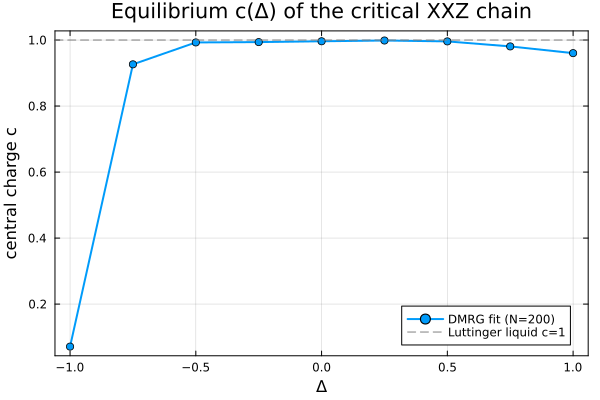

In [2]:
using JLD2, LsqFit
# von Neumann entropy across every bond of an MPS (same helper as nb4).
function compute_vn_entropy(psi::MPS)
    N=length(psi); S=Float64[]
    for b in 1:N-1
        orthogonalize!(psi,b)
        ib = b==1 ? (siteind(psi,b),) : (linkind(psi,b-1), siteind(psi,b))
        _,Sv,_ = svd(psi[b], ib); s=0.0
        for n in 1:dim(Sv,1); pr=Sv[n,n]^2; pr>1e-12 && (s-=pr*log(pr)); end
        push!(S,s)
    end
    S
end

DMRGFILE="../results/data/nb9_xxz_dmrg.jld2"
function xxz_c_sweep()
    isfile(DMRGFILE) && return load(DMRGFILE,"res")
    N=200; sites=siteinds("S=1/2",N); bonds=collect(1:N-1)
    @. chord(x,q)=(q[1]/6)*x+q[2]
    res=Dict{Float64,Float64}()
    for Δ in -1.0:0.25:1.0
        H=MPO(xxz_opsum(N,-1.0,Δ), sites)
        _,psi=dmrg(H, randomMPS(sites,10); nsweeps=18, maxdim=[10,20,100,200,400],
                   cutoff=[1e-10], noise=[1e-4,1e-5,1e-6,0.0], outputlevel=0)
        S=compute_vn_entropy(psi)
        xv=log.((2N/pi).*sin.(pi.*bonds./N)); bulk=findall(b->N/4<=b<=3N/4, bonds)
        c=curve_fit(chord, xv[bulk], S[bulk], [1.0,1.0]).param[1]
        res[Δ]=c; @printf("Δ=%+.2f  c=%.3f\n",Δ,c)
    end
    jldsave(DMRGFILE; res=res); res
end
res=xxz_c_sweep()

Δs=sort(collect(keys(res))); cs=[res[Δ] for Δ in Δs]
plt=plot(Δs, cs; marker=:circle, lw=2, label="DMRG fit (N=200)", xlabel="Δ", ylabel="central charge c",
         framestyle=:box, grid=true, title="Equilibrium c(Δ) of the critical XXZ chain")
hline!(plt,[1.0]; ls=:dash, color=:gray, label="Luttinger liquid c=1")
mkpath("../results/imgs"); savefig(plt,"../results/imgs/xxz_c_equilibrium.png"); plt

## 2. Why the naive uniform state $|X+\rangle$ fails here

For the **Alcaraz** model the quench used $|X+\rangle$ (all spins along $+x$): that model has a transverse
field, so $|X+\rangle$ is the field-polarized paramagnet — far from the $ZZ$-ordered eigenstates, a strong
quench. **XXZ has no field.** Its ferromagnetic state is itself a *uniform product state*, so any uniform
single-site product state sits close to an eigenstate, and produces almost **no temporal entanglement**.

The cell below makes this concrete: quenching $|X+\rangle$ with XXZ, the transfer-matrix fixed point is a
near-**product** temporal MPS ($\chi\!\approx\!4$, $\mathrm{Re}\,S_2\!\approx\!0$) — no conformal dome —
even though the Loschmidt echo itself decays normally. (The echo decays because $|\lambda_0|<1$; the
*entanglement* is what stays zero.) So $|X+\rangle$ cannot deliver the log we are after, and we need a
genuinely entangling quench.

In [3]:
# |X+> quenched with XXZ: the temporal entropy is ~0 (near-product fixed point), for several T.
XPFILE="../results/data/nb9_xplus_trivial.jld2"
function xplus_trivial()
    isfile(XPFILE) && return load(XPFILE,"d")
    d=Dict{Float64,Any}()
    for T in [3.0,4.0,5.0]
        r=compute_entropies(XXZParams(-1.0,0.5,0.0), T; scheme=XXZVD2(), init_state="X+",
                            dt=0.05, nbeta=4, maxdim=64, use_block_pm=true, k_block=2)
        d[T]=(peak=maximum(r.re[3:end-2]), chi=maxlinkdim(r.R))
    end
    jldsave(XPFILE; d=d); d
end
d=xplus_trivial()
@printf("%-6s %-12s %-6s\n","T","Re S2 peak","χ")
for T in sort(collect(keys(d))); @printf("%-6.0f %-12.4f %-6d\n",T,d[T].peak,d[T].chi); end
println("\n⇒ flat ~0 dome, χ≈4 (near-product): |X+> is not an entangling quench for XXZ.")

┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Warning: Tensor *not* symmetric (dim=2|id=524|"S=1/2,Site") <-> (dim=2|id=524|"S=1/2,Site")', normdiff = 0.5015821322741338
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=13|id=600|"Link,l=1") <-> (dim=13|id=303|"Link,l=2"), normdiff = 0.5635311728844289
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Warning: Tensor *not* symm

T      Re S2 peak   χ     
3      -0.0066      4     


┌ Warning: log(norm²) is -0.22839831086400064 + 2.268644113257016e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS /home/jmarquezol/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1271


4      -0.0071      4     
5      -0.0065      6     

⇒ flat ~0 dome, χ≈4 (near-product): |X+> is not an entangling quench for XXZ.


## 3. The Néel quench, via a sublattice rotation

The physically correct, strongly-entangling XXZ quench is from the **Néel state**
$|{\uparrow\downarrow\uparrow\downarrow\cdots}\rangle$ — the $\Delta\!\to\!\infty$ ordered state, maximally
far from the critical dynamics (it is the canonical XXZ quench, and the setting of the well-known
even/odd *parity oscillations* in the entanglement). Néel is a **2-site unit cell**, which the
single-site transverse machinery does not directly take.

We avoid building a 2-site boundary with a **sublattice rotation**
$R=\prod_{x\ \mathrm{even}}e^{i\pi S^x_x}$ (a $\pi$-flip on every other site). $R$ maps
$|{\rm N\acute{e}el}\rangle\to|{\uparrow\uparrow\uparrow\cdots}\rangle$ (uniform) and

$$\mathcal H_\Delta \;\longrightarrow\; \mathcal H'_\Delta=\sum_x\Big[\tfrac12\big(S^+_xS^+_{x+1}+S^-_xS^-_{x+1}\big)-\Delta\,S^z_xS^z_{x+1}\Big].$$

Because $R$ is a product of **single-site** unitaries, the Loschmidt echo and the entire temporal-entropy
structure are *identical*: studying $(|{\uparrow}\rangle,\mathcal H'_\Delta)$ **is** the Néel quench of
$(|{\rm N\acute{e}el}\rangle,\mathcal H_\Delta)$, but now with a uniform $|{\uparrow}\rangle$ boundary that
the single-site machinery handles. Note the $ZZ$ sign **flips to $-\Delta$** in the rotated frame (any
Néel$\to$ferromagnet rotation is a $\pi$-rotation in the $xy$ plane, which flips $S^z$); `xxz_neel_opsum`
takes the **physical** $+\Delta$ and applies this internally. The cell below verifies the equivalence
against TDVP.

In [4]:
using ITensorMPS
# Echo equivalence: TDVP of |Néel> under H_Δ  ==  MPO-apply of |↑> under H'_Δ (rotated). Δ physical.
ECHOFILE="../results/data/nb9_neel_echo.jld2"
function neel_echo_check(Δ=0.5)
    isfile(ECHOFILE) && return load(ECHOFILE,"d")
    N=20; dt=0.05; Ts=[1.0,2.0,3.0,4.0]; sites=siteinds("S=1/2",N)
    # (a) direct: |Néel> under the TRUE XXZ, TDVP
    Hxxz=MPO(xxz_opsum(N,-1.0,Δ), sites)
    neel=complex(MPS(sites, [isodd(i) ? "Up" : "Dn" for i in 1:N]))
    eD=Float64[]
    for T in Ts
        psi=deepcopy(neel)
        for _ in 1:round(Int,T/dt); psi=tdvp(Hxxz,-im*dt,psi; nsweeps=1, cutoff=1e-10, maxdim=128, outputlevel=0); end
        push!(eD, abs(inner(neel,psi)))
    end
    # (b) rotated: |↑> under H'_Δ, exp-MPO apply
    psi0=complex(MPS(sites,"Up")); U=expH_xxz_neel(sites, Δ; dt=dt, mpo_alg="VD2")
    eR=Float64[]
    for T in Ts
        psi=deepcopy(psi0)
        for _ in 1:round(Int,T/dt); psi=apply(U,psi; cutoff=1e-12, maxdim=200); normalize!(psi); end
        push!(eR, abs(inner(psi0,psi)))
    end
    d=(Ts=Ts, eD=eD, eR=eR); jldsave(ECHOFILE; d=d); d
end
d=neel_echo_check()
@printf("%-5s %-16s %-16s\n","T","|L| Néel/H (TDVP)","|L| ↑/H' (MPO)")
for (i,T) in enumerate(d.Ts); @printf("%-5.0f %-16.4f %-16.4f\n",T,d.eD[i],d.eR[i]); end
@printf("max|Δecho| = %.2e  ⇒ rotation equivalence confirmed\n", maximum(abs.(d.eD.-d.eR)))

T     |L| Néel/H (TDVP) |L| ↑/H' (MPO)  
1     0.0714           0.0713          
2     0.0011           0.0011          
3     0.0059           0.0058          
4     0.0310           0.0310          
max|Δecho| = 3.95e-05  ⇒ rotation equivalence confirmed


## 4. Validating the rotated propagator

The temporal-entropy pipeline applies the exp-MPO $U(\delta t)=e^{-i\mathcal H'_\Delta\,\delta t}$ built with
our **VD2** (2nd-order) kernel. The echo agreement above already shows the VD2 propagator of $\mathcal H'_\Delta$
reproduces the exact dynamics (the TDVP curve is the ground truth and the VD2-MPO curve lands on it to
$\sim\!10^{-4}$). As with Alcaraz, the **MPO is therefore not the suspect** if anything looks off downstream —
the transverse contraction is. We use $\delta t=0.05$, $n_\beta=4$ ($\beta_0=0.2$ UV regulator) throughout.

## Summary

- The XXZ chain is critical with **$c=1$** across $|\Delta|\le1$ (DMRG), with the expected Heisenberg-point
  overshoot from the marginal operator.
- The uniform $|X+\rangle$ quench gives **no temporal entanglement** for XXZ (no field ⇒ near an eigenstate).
- The **Néel quench** is the entangling one; via the single-site **sublattice rotation** it becomes the
  uniform $|{\uparrow}\rangle$ quench of $\mathcal H'_\Delta$, with **identical** observables (echo verified to
  $10^{-4}$ vs TDVP). This keeps the single-site transverse machinery.

Notebook 9 computes the generalized temporal entropy of this quench, extracts $c$, and examines the
oscillations.